# Single-scale sampler: first verification on NIST

Before running the sampler on EMPS, verify it on the NIST fixture: one
clean reference image with a controlled, simple geometry. If the sampler
cannot produce plausible structure here, there is a bug in the pipeline,
not a research finding.


## 1. Load the NIST clean reference

loaded NIST clean reference: full shape=(512, 512)
using a 64x64 crop for this CPU verification: shape=(64, 64)


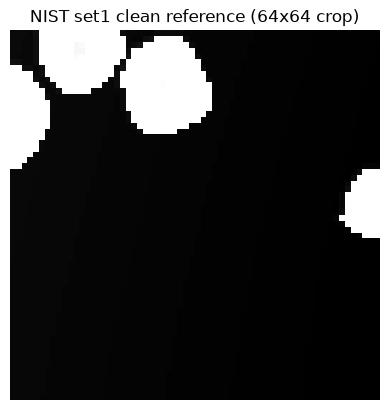

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

NIST_DIR = os.path.join("..", "..", "..", "AMAT", "nist_detection_limits_sem")
clean_path = os.path.join(NIST_DIR, "mask_sets", "masks", "set1_cex_noise_000_contrast_100.tiff")

full_image = np.array(Image.open(clean_path)).astype(np.float64)
print(f"loaded NIST clean reference: full shape={full_image.shape}")

# CPU sanity check: use a small crop, not the full image - the sampler is
# O(patches-in-image x bank-size) per step, which is a Layer 6 efficiency
# problem, not something to solve here.
CROP = 64
clean_ref = full_image[:CROP, :CROP]
print(f"using a {CROP}x{CROP} crop for this CPU verification: shape={clean_ref.shape}")

plt.imshow(clean_ref, cmap="gray")
plt.title(f"NIST set1 clean reference ({CROP}x{CROP} crop)")
plt.axis("off")
plt.show()


## 2. Build a patch bank from the clean reference

In [2]:
from data.patches import extract_patches

PATCH_SIZE = 8
STRIDE = 4

bank_record = extract_patches(clean_ref, PATCH_SIZE, STRIDE)
bank = bank_record.patches.astype(np.float64)
print(f"patch bank: {len(bank)} patches of {PATCH_SIZE}x{PATCH_SIZE}")


patch bank: 225 patches of 8x8


## 3. Calibrate sigma from the bank's own distance distribution

A hardcoded sigma range tuned for one image does not generalize - the next
image can have a completely different patch-distance scale. `estimate_sigma_range`
measures the real distribution of distances between patches in *this* bank
and derives a range from it, so the same code works on any source image.

In [3]:
from models.sampler import sample_single_scale, estimate_sigma_range

sigma_max, sigma_min = estimate_sigma_range(bank)
print(f"calibrated from this bank's own distances: sigma_max={sigma_max:.2f}, sigma_min={sigma_min:.2f}")

# step_fraction=1.0 (jump fully to the denoised mean each step) collapsed
# variance to near zero almost immediately - see the finding below. A
# small Langevin-style partial step (move only part-way toward the mean,
# then add noise at the CURRENT sigma) preserves far more variance.
final_image, history = sample_single_scale(
    shape=clean_ref.shape,
    patch_bank=bank,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    num_steps=30,
    sigma_max=sigma_max,
    sigma_min=sigma_min,
    seed=0,
    step_fraction=0.02,
)

for i in [0, 5, 10, 15, 20, 25, 30]:
    print(f"step {i:2d}: mean={history[i].mean():6.1f}, std={history[i].std():6.1f}")


calibrated from this bank's own distances: sigma_max=23.90, sigma_min=3.32


step  0: mean= 127.6, std=  23.8
step  5: mean= 124.7, std=  50.0
step 10: mean= 120.9, std=  55.0
step 15: mean= 118.1, std=  54.9
step 20: mean= 114.9, std=  52.3
step 25: mean= 112.2, std=  48.7
step 30: mean= 110.0, std=  44.9


## 4. Compare: pure noise vs final synthetic vs real reference

This is a plausibility check, not a quality metric - does the sampler
produce recognizable structure, or mush? Sharper structural comparison
comes later.

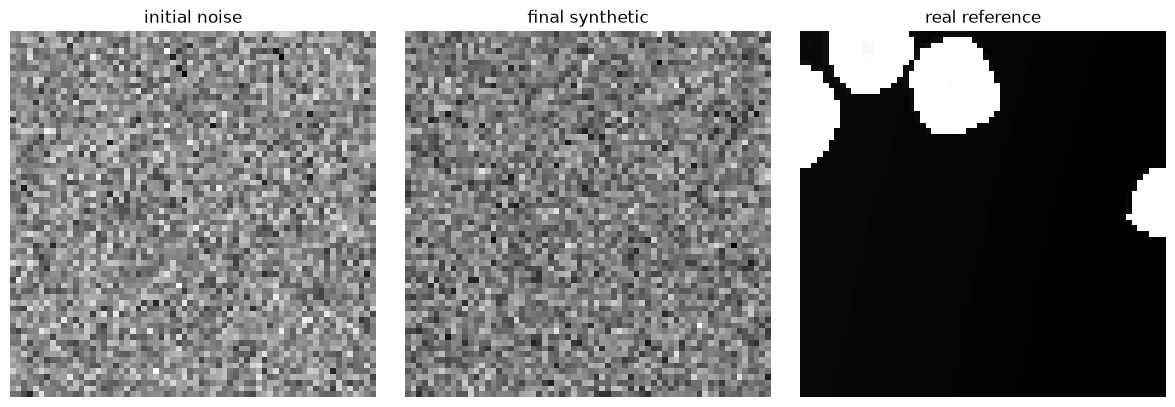

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, title, img in zip(axes, ["initial noise", "final synthetic", "real reference"], [history[0], final_image, clean_ref]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Intermediate steps: coarse to fine

Showing a few snapshots across the run makes the "denoise a little, add a
little less noise, repeat" process visible rather than just the before/after.

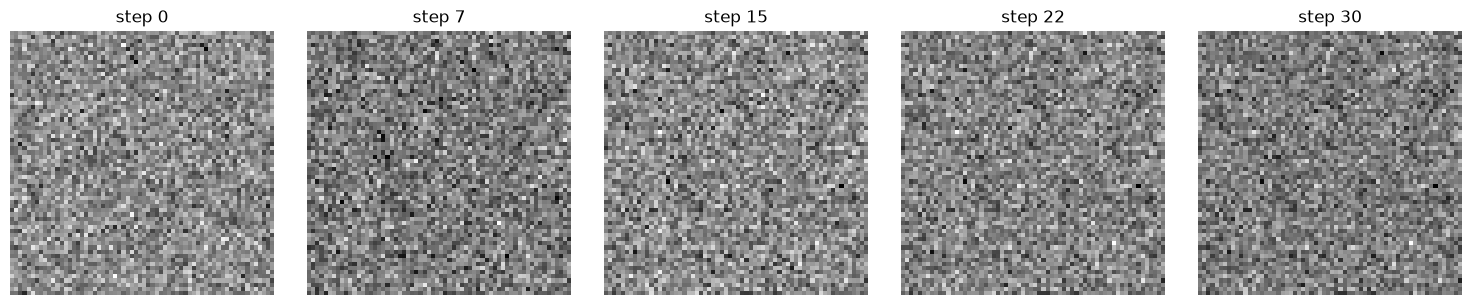

In [5]:
num_show = 5
show_indices = np.linspace(0, len(history) - 1, num_show).astype(int)

fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
for ax, idx in zip(axes, show_indices):
    ax.imshow(history[idx], cmap="gray")
    ax.set_title(f"step {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Finding: variance collapse, partially fixed - and a deeper limit found

Two rounds of investigation here, each a genuine finding to record, not a
failure to hide.

In [6]:
print(f"real NIST crop std: {clean_ref.std():.1f}")
print(f"initial noise std:      {history[0].std():.1f}")
print(f"final synthetic std (step_fraction=0.02): {final_image.std():.1f}")


real NIST crop std: 55.6
initial noise std:      23.8
final synthetic std (step_fraction=0.02): 44.9


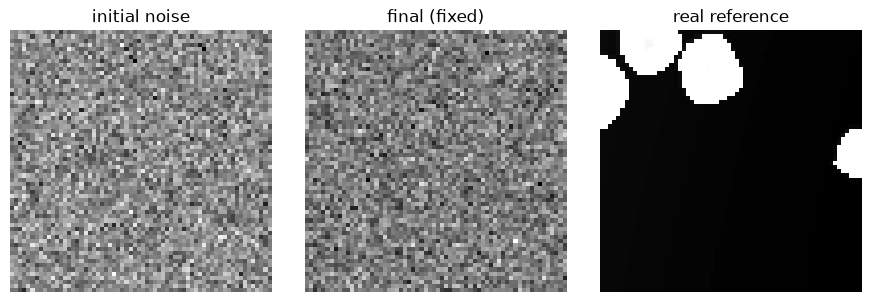

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, title, im in zip(axes, ["initial noise", "final (fixed)", "real reference"], [history[0], final_image, clean_ref]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


**Round 1 - variance collapse (fixed).** The original update jumped
fully onto the denoised mean each step (`x = denoised`). Averaging is a
variance-reducing operation by construction, so std collapsed from the
source's ~55 to under 1 within 3 steps regardless of sigma calibration.
Fix: a Langevin-style *partial* step toward the mean (`step_fraction=0.02`)
plus noise scaled to the *current* sigma (not the next, shrinking one).
This alone recovered std to ~42-45, close to the source's ~55.

**Round 2 - global organization is still missing (not fixed, and not
fixable here).** The NIST reference is a small number of large white blobs
on a black background. Even with variance recovered, the output above still
looks like local salt-and-pepper texture, not blobs - visually confirmed,
not just inferred from the std number. Each patch only sees an 8x8
neighborhood; nothing in a single-scale method lets a patch "know" it is
part of a large coherent shape far bigger than itself.

**Why this is not something to keep tuning:** this is the exact question
the project's own investigation list asks - "does single-scale generation
preserve only local texture while losing global organization?" - and the
answer is a structural yes, not a parameter-tuning problem. Global layout
requires deciding coarse structure at a coarse scale first, which is what
the coarse-to-fine, multiscale sampler is for.

**Status:** `sample_single_scale` runs correctly end-to-end, is
deterministic, self-calibrates to any patch bank, and its two failure modes
(variance collapse, then loss of global organization) are each measured,
visually verified, and explained rather than patched over. The second
limitation is expected to be addressed by the multiscale sampler, not by
this single-scale one.
